# 🛍️ Shopping Mall Customer Segmentation
## Member 3 — DBSCAN Clustering

---
### 📌 How DBSCAN Works (Simple Explanation)

DBSCAN = Density-Based Spatial Clustering of Applications with Noise

Think of it like finding crowded areas in a shopping mall:
1. Look at each customer's surroundings within a radius (`eps`)
2. If enough customers are nearby (`min_samples`) → it's a cluster
3. Keep expanding the cluster as long as the area stays dense
4. Customers in empty areas = **noise/outliers** (label = -1)

**Key advantages over K-Means:**
- Does NOT need K specified upfront
- Finds clusters of any shape (not just round ones)
- Identifies outlier customers automatically

> ⚠️ Run `step0_eda_preprocessing.ipynb` first!

---
## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from joblib import dump, load
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

X_scaled = np.load('X_scaled.npy')
df_clean = pd.read_csv('data_preprocessed.csv')
df       = pd.read_csv('Shopping_Mall_Customer_Segmentation_Data_.csv')

scaler = StandardScaler()
scaler.fit(df_clean)

print('✅ Data loaded')
print(f'   Customers : {len(df_clean):,}')

✅ Data loaded
   Customers : 15,079


---
## Step 2: Find Optimal eps — K-Distance Graph

### 📌 What is eps and how do we find it?
`eps` = the radius DBSCAN uses to search for neighbours.
- Too small → everything becomes noise
- Too large → everything merges into one cluster

**K-Distance Graph method:**
- Calculate the distance from each point to its K-th nearest neighbour
- Sort these distances
- The **elbow point** of the curve = good eps value

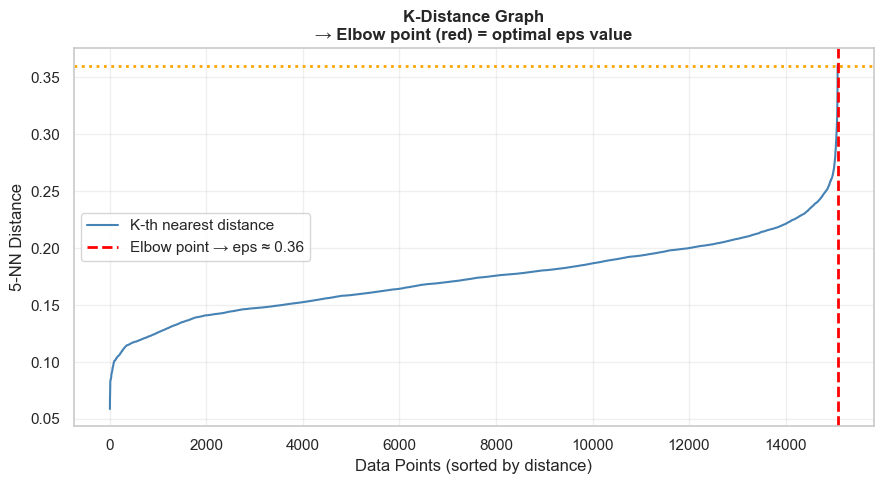

📊 Suggested eps ≈ 0.36
   → The elbow is where the curve bends sharply.
   → Points above the elbow = sparse (noise); below = dense (clusters).


In [3]:
MIN_SAMPLES = 5
nbrs        = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _= nbrs.kneighbors(X_scaled)
distances   = np.sort(distances[:, -1])  # sort k-th nearest distances

# Find elbow automatically using maximum curvature
d1   = np.diff(distances)
d2   = np.diff(d1)
elbow_idx = np.argmax(d2) + 2
suggested_eps = round(distances[elbow_idx], 2)

plt.figure(figsize=(9, 5))
plt.plot(distances, color='steelblue', linewidth=1.5, label='K-th nearest distance')
plt.axvline(x=elbow_idx, color='red', linestyle='--', linewidth=2,
            label=f'Elbow point → eps ≈ {suggested_eps}')
plt.axhline(y=suggested_eps, color='orange', linestyle=':', linewidth=2)
plt.xlabel('Data Points (sorted by distance)')
plt.ylabel(f'{MIN_SAMPLES}-NN Distance')
plt.title('K-Distance Graph\n→ Elbow point (red) = optimal eps value', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', bbox_inches='tight')
plt.show()
print(f'📊 Suggested eps ≈ {suggested_eps}')
print('   → The elbow is where the curve bends sharply.')
print('   → Points above the elbow = sparse (noise); below = dense (clusters).')

---
## Step 3: Parameter Grid Search — Find Best eps & min_samples

In [4]:
print('DBSCAN Parameter Search:')
print(f'{"eps":>6} | {"min_samples":>12} | {"Clusters":>9} | {"Noise %":>8} | {"Silhouette":>11}')
print('-' * 58)

best_sil    = -1
best_params = {'eps': suggested_eps, 'min_samples': MIN_SAMPLES}
results     = []

for eps in [suggested_eps * 0.7, suggested_eps, suggested_eps * 1.3, suggested_eps * 1.6]:
    eps = round(eps, 2)
    for min_s in [3, 5, 10]:
        db     = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)
        n_c    = len(set(labels)) - (1 if -1 in labels else 0)
        noise  = (labels == -1).sum() / len(labels) * 100
        mask   = labels != -1
        sil    = silhouette_score(X_scaled[mask], labels[mask]) if n_c >= 2 and mask.sum() > 1 else -1
        results.append({'eps': eps, 'min_s': min_s, 'n_c': n_c, 'noise': noise, 'sil': sil})
        print(f'{eps:>6.2f} | {min_s:>12} | {n_c:>9} | {noise:>7.1f}% | {sil:>11.4f}')
        if n_c >= 2 and sil > best_sil:
            best_sil    = sil
            best_params = {'eps': eps, 'min_samples': min_s}

print(f'\n✅ Best params: eps={best_params["eps"]}, min_samples={best_params["min_samples"]} (Silhouette={best_sil:.4f})')

DBSCAN Parameter Search:
   eps |  min_samples |  Clusters |  Noise % |  Silhouette
----------------------------------------------------------
  0.25 |            3 |         3 |     0.0% |      0.1542
  0.25 |            5 |         2 |     0.1% |      0.2637
  0.25 |           10 |         5 |     1.9% |      0.0524
  0.36 |            3 |         2 |     0.0% |      0.2635
  0.36 |            5 |         2 |     0.0% |      0.2635
  0.36 |           10 |         2 |     0.0% |      0.2635
  0.47 |            3 |         2 |     0.0% |      0.2635
  0.47 |            5 |         2 |     0.0% |      0.2635
  0.47 |           10 |         2 |     0.0% |      0.2635
  0.58 |            3 |         2 |     0.0% |      0.2635
  0.58 |            5 |         2 |     0.0% |      0.2635
  0.58 |           10 |         2 |     0.0% |      0.2635

✅ Best params: eps=0.25, min_samples=5 (Silhouette=0.2637)


---
## Step 4: Train Final DBSCAN Model

In [5]:
dbscan        = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
cluster_labels= dbscan.fit_predict(X_scaled)

n_clusters    = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise       = (cluster_labels == -1).sum()

df_clean['Cluster'] = cluster_labels
df['Cluster']       = cluster_labels

print(f'✅ DBSCAN trained (eps={best_params["eps"]}, min_samples={best_params["min_samples"]})')
print(f'   Clusters found : {n_clusters}')
print(f'   Noise points   : {n_noise} ({n_noise/len(df)*100:.1f}%)')
print()
print('Cluster Distribution:')
for c, count in zip(*np.unique(cluster_labels, return_counts=True)):
    label = 'NOISE (outlier)' if c == -1 else f'Cluster {c}'
    pct   = count / len(df) * 100
    print(f'  {label:20s}: {count:5,} customers ({pct:.1f}%)')

✅ DBSCAN trained (eps=0.25, min_samples=5)
   Clusters found : 2
   Noise points   : 18 (0.1%)

Cluster Distribution:
  NOISE (outlier)     :    18 customers (0.1%)
  Cluster 0           : 7,587 customers (50.3%)
  Cluster 1           : 7,474 customers (49.6%)


---
## Step 5: Evaluate the Model

In [6]:
mask = cluster_labels != -1
sil  = silhouette_score(X_scaled[mask], cluster_labels[mask]) if mask.sum() > 1 else -1
dbi  = davies_bouldin_score(X_scaled[mask], cluster_labels[mask]) if mask.sum() > 1 else -1

print('=' * 55)
print('     DBSCAN EVALUATION METRICS')
print('=' * 55)
print(f'  eps                 : {best_params["eps"]}')
print(f'  min_samples         : {best_params["min_samples"]}')
print(f'  Clusters found      : {n_clusters}')
print(f'  Noise points        : {n_noise} ({n_noise/len(df)*100:.1f}%)')
print(f'  Silhouette Score    : {sil:.4f}  (closer to 1 = better)')
print(f'  Davies-Bouldin Index: {dbi:.4f}  (closer to 0 = better)')
print('  Note: Metrics computed on non-noise points only')
print('=' * 55)

scores = {'algorithm': 'DBSCAN', 'n_clusters': n_clusters,
          'silhouette': round(sil, 4), 'davies_bouldin': round(dbi, 4),
          'inertia': 'N/A', 'noise': n_noise}
pickle.dump(scores,        open('dbscan_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('dbscan_labels.pkl', 'wb'))
print('\n✅ Scores saved.')

     DBSCAN EVALUATION METRICS
  eps                 : 0.25
  min_samples         : 5
  Clusters found      : 2
  Noise points        : 18 (0.1%)
  Silhouette Score    : 0.2637  (closer to 1 = better)
  Davies-Bouldin Index: 1.6628  (closer to 0 = better)
  Note: Metrics computed on non-noise points only

✅ Scores saved.


---
## Step 6: 3D Cluster Visualisation

In [ ]:
unique_labels = sorted(set(cluster_labels))
palette       = sns.color_palette('tab10', n_clusters)
color_map     = {c: palette[i] for i, c in enumerate(l for l in unique_labels if l != -1)}

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

# Plot noise first (grey)
if n_noise > 0:
    nm = cluster_labels == -1
    ax.scatter(df.loc[nm,'Annual Income'], df.loc[nm,'Spending Score'], df.loc[nm,'Age'],
               c='lightgray', s=5, alpha=0.2, label=f'Noise ({n_noise} outliers)', marker='x')

# Plot clusters
for c in unique_labels:
    if c == -1: continue
    mask = cluster_labels == c
    ax.scatter(df.loc[mask,'Annual Income'], df.loc[mask,'Spending Score'], df.loc[mask,'Age'],
               color=color_map[c], label=f'Cluster {c}', alpha=0.5, s=10)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title(f'DBSCAN 3D Cluster View ({n_clusters} clusters + noise)\n→ Grey X = outlier customers that fit no group',
             fontweight='bold')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('dbscan_3d.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   → Grey X markers = noise/outlier customers')
print('   → DBSCAN is the only algorithm that identifies these outliers!')
print('   → Clusters are found based on density, not distance to a centre.')

---
## Step 7: Cluster Profile Analysis

In [ ]:
df_no_noise = df[df['Cluster'] != -1]
profile     = df_no_noise.groupby('Cluster')[['Age','Annual Income','Spending Score']].mean().round(1)
profile['Count']      = df_no_noise.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(1)
print('=== Cluster Profiles (excluding noise) ===')
print(profile)

plt.figure(figsize=(8, max(3, n_clusters * 0.8 + 2)))
heatmap_data = df_no_noise.groupby('Cluster')[['Age','Annual Income','Spending Score']].mean()
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
plt.title('DBSCAN Cluster Profile Heatmap\n→ Noise points excluded from analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_heatmap.png', bbox_inches='tight')
plt.show()

---
## Step 8: Save Model & Predict New Customer

### 📌 DBSCAN Prediction Note
DBSCAN has no `.predict()` like K-Means.
Instead we find the nearest core point and use its cluster label.

In [ ]:
dump(dbscan, 'dbscan_model.joblib')
# Save training data for nearest-neighbour prediction
pickle.dump({'X_train': X_scaled, 'labels': cluster_labels},
            open('dbscan_train_data.pkl', 'wb'))
print('✅ Model saved: dbscan_model.joblib')
print('✅ Train data saved: dbscan_train_data.pkl (needed for prediction)')

In [ ]:
train_data   = pickle.load(open('dbscan_train_data.pkl', 'rb'))
X_train      = train_data['X_train']
train_labels = train_data['labels']

cluster_names = {
    0 : 'Budget-Conscious Customers',
    1 : 'VIP / High Spenders',
    2 : 'Average Customers',
    -1: 'Outlier / Unusual Customer'
}  # Update based on your profiles!

print('=== Enter New Customer Details ===')
input_age            = int(input('Enter Age              : '))
input_gender         = input('Enter Gender (Male/Female): ').strip().capitalize()
input_annual_income  = float(input('Enter Annual Income    : '))
input_spending_score = float(input('Enter Spending Score (1-100): '))

gender_encoded      = 0 if input_gender == 'Female' else 1
new_customer        = np.array([[input_age, gender_encoded, input_annual_income, input_spending_score]])
new_customer_scaled = scaler.transform(new_customer)

# Find nearest neighbour → use its cluster label
nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_train)
_, indices      = nn.kneighbors(new_customer_scaled)
predicted_cluster = train_labels[indices[0][0]]

print()
print('=' * 45)
print('         PREDICTION RESULT')
print('=' * 45)
print(f'  Predicted Cluster : {predicted_cluster}')
print(f'  Segment Name      : {cluster_names.get(predicted_cluster, "Segment " + str(predicted_cluster))}')
if predicted_cluster != -1:
    cluster_avg = df[df['Cluster'] == predicted_cluster][['Age','Annual Income','Spending Score']].mean()
    print(f'  Cluster Avg Age   : {cluster_avg["Age"]:.0f}')
    print(f'  Cluster Avg Income: {cluster_avg["Annual Income"]:,.0f}')
    print(f'  Cluster Avg Score : {cluster_avg["Spending Score"]:.0f}')
else:
    print('  → This customer is unusual and does not fit any existing cluster.')
print('=' * 45)

In [ ]:
# 3D prediction plot
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

if n_noise > 0:
    nm = cluster_labels == -1
    ax.scatter(df.loc[nm,'Annual Income'], df.loc[nm,'Spending Score'], df.loc[nm,'Age'],
               c='lightgray', s=5, alpha=0.1, marker='x', label='Noise')

for c in unique_labels:
    if c == -1: continue
    mask  = cluster_labels == c
    alpha = 0.6 if c == predicted_cluster else 0.15
    lbl   = f'Cluster {c} ← YOU' if c == predicted_cluster else f'Cluster {c}'
    ax.scatter(df.loc[mask,'Annual Income'], df.loc[mask,'Spending Score'], df.loc[mask,'Age'],
               color=color_map[c], label=lbl, alpha=alpha, s=10)

ax.scatter([input_annual_income], [input_spending_score], [input_age],
           marker='*', s=800, c='gold', edgecolors='black', linewidths=1.5,
           zorder=10, label='New Customer ⭐')

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title(f'DBSCAN — New Customer → Cluster {predicted_cluster}', fontweight='bold')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('dbscan_prediction.png', bbox_inches='tight')
plt.show()